# Transformer Model - on textual embeddings 64
This notebook follows the same data-loading and split logic used by the embedding-based KNN and XGBoost notebooks, but trains `PairEmbeddingTransformerModel`, a `BaseModel` implementation defined in `utils/model_classes.py`.

The model logic is kept in the shared class; the notebook focuses on loading data, configuring the run, training, evaluating, saving, and optionally reloading the checkpoint.


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

TEXTUAL_EMBEDDING_PATH = PROJECT_ROOT / 'data' / 'textual_features'
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'
text_emb_64 = TEXTUAL_EMBEDDING_PATH / 'textual_embeddings_64.parquet'

RANDOM_STATE = 42

from utils.embedding_transformer_utils import (
    get_torch_device,
    load_pair_embedding_transformer_model,
    sample_dataframe,
    set_torch_seed,
)
from utils.model_classes import PairEmbeddingTransformerModel

RANDOM_STATE = 42
DEVICE = get_torch_device()

print(f"Project root: {PROJECT_ROOT}")
print(f"Embeddings: {text_emb_64}")
print(f"Device: {DEVICE}")

Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Data: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/exploded_splits
Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Embeddings: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/textual_features/textual_embeddings_64.parquet
Device: cuda


## 1. Load embedding data

In [4]:
# Stesso split usato nei notebook KNN/XGB.
split_series = df["split"].astype(str).str.lower()
df_train = df[split_series == "train"].copy()
df_val = df[split_series.isin(["validation", "val"])].copy()
df_test = df[split_series == "test"].copy()

ID_COLUMNS = ["article_id", "ref_id"]
df_train = df_train.drop(columns=ID_COLUMNS, errors="ignore")
df_val = df_val.drop(columns=ID_COLUMNS, errors="ignore")
df_test = df_test.drop(columns=ID_COLUMNS, errors="ignore")

print("Split sizes:", {"train": len(df_train), "val": len(df_val), "test": len(df_test)})

Split sizes: {'train': 2162513, 'val': 391242, 'test': 396380}


## 2. Transformer baseline model
As in the KNN notebook, this section defines the model configuration and the working dataset. Sample limits are useful for fast trial runs; set them to `None` to train on the full splits.


In [5]:
set_torch_seed(RANDOM_STATE)

MAX_TRAIN_SAMPLES = len(df_train)
MAX_VAL_SAMPLES = len(df_val)
MAX_TEST_SAMPLES = len(df_test)

TRAINING_PARAMS = {
    "epochs": 15,
    "batch_size": 512,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "patience": 2,
}

MODEL_PARAMS = {
    "embedding_dim": 64,
    "d_model": 64,
    "nhead": 8,
    "num_layers": 2,
    "dim_feedforward": 128,
    "dropout": 0.15,
}

# Campionamento solo per velocizzare gli esperimenti: non cambia il formato dati.
df_train_model = sample_dataframe(df_train, MAX_TRAIN_SAMPLES, RANDOM_STATE)
df_val_model = sample_dataframe(df_val, MAX_VAL_SAMPLES, RANDOM_STATE)
df_test_model = sample_dataframe(df_test, MAX_TEST_SAMPLES, RANDOM_STATE)

print("Model split sizes:", {"train": len(df_train_model), "val": len(df_val_model), "test": len(df_test_model)})

Model split sizes: {'train': 2162513, 'val': 391242, 'test': 396380}


In [6]:
# Classe definita in utils/model_classes.py e derivata da BaseModel.
transformer_model = PairEmbeddingTransformerModel(
    model_name="pair_embedding_transformer_64",
    device=DEVICE,
    **MODEL_PARAMS,
)

print(transformer_model.model)
print("Trainable parameters:", sum(p.numel() for p in transformer_model.model.parameters() if p.requires_grad))

PairEmbeddingTransformer(
  (input_projection): Linear(in_features=64, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.15, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.15, inplace=False)
        (dropout2): Dropout(p=0.15, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential(
    (0): Dropout(p=0.15, inplace=False)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2):

/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[pair_embedding_transformer_64] Preprocessing data...
Label distribution:
1.0    0.500002
0.0    0.499998
Name: proportion, dtype: float64
[pair_embedding_transformer_64] Preprocessing data...
[pair_embedding_transformer_64] Starting training...


epoch 1 train:   0%|          | 0/4224 [00:00<?, ?it/s]

predict:   0%|          | 0/765 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.46672407735433036, 'val_f1_weighted': 0.8372772165447777}


epoch 2 train:   0%|          | 0/4224 [00:00<?, ?it/s]

...

epoch 15 train:   0%|          | 0/4224 [00:00<?, ?it/s]

predict:   0%|          | 0/765 [00:00<?, ?it/s]

{'epoch': 15, 'train_loss': 0.27268236552414055, 'val_f1_weighted': 0.8825525507651417}


predict:   0%|          | 0/4224 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.9138    0.8839    0.8986   1081253
           1     0.8876    0.9166    0.9018   1081260

    accuracy                         0.9002   2162513
   macro avg     0.9007    0.9002    0.9002   2162513
weighted avg     0.9007    0.9002    0.9002   2162513



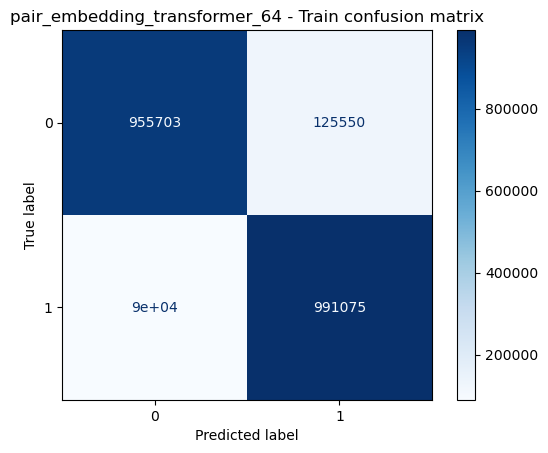

In [7]:
# Train pipeline in stile KNNModel:
# 1. preprocess train con fit dello scaler
# 2. preprocess validation con lo stesso scaler
# 3. training PyTorch
# 4. valutazione sul train
train_metrics = transformer_model.train_pipeline(
    df_train_model,
    raw_val=df_val_model,
    **TRAINING_PARAMS,
)

The transformer model that uses the 64-dimensional textual features achieves an accuracy of 90.02% on the validation set. The confusion matrix shows that the the model reach some kind of balance between the two categories, predicting both valid and invalid citations corretcly 88% of the time.

,epoch,train_loss,val_f1_weighted
0,1,0.466724,0.837277
1,2,0.360993,0.853121
2,3,0.335538,0.860672
3,4,0.320642,0.865072
4,5,0.311082,0.870037
5,6,0.303721,0.872651
6,7,0.297752,0.874555
7,8,0.292624,0.875903
8,9,0.288752,0.876205
9,10,0.284833,0.878894


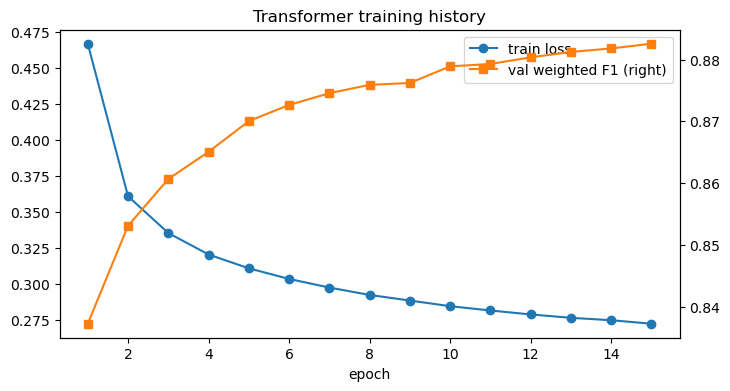

In [8]:
history_df = pd.DataFrame(transformer_model.history)
display(history_df)

if len(history_df) > 0:
    ax = history_df.plot(x="epoch", y="train_loss", marker="o", figsize=(8, 4), label="train loss")
    if "val_f1_weighted" in history_df.columns:
        history_df.plot(x="epoch", y="val_f1_weighted", marker="s", secondary_y=True, ax=ax, label="val weighted F1")
    plt.title("Transformer training history")
    plt.show()

From the training plot, we can notice how already at the start of the training loop, the model start with almost 84% of accuracy. This show how the baseline of the transformer model can reach such high performance from the textual features. The loss have a similar pattern, it start from 0.475 and decrease up to 0.2 after 15 epochs.

## 3. Final model evaluation
After training, the same model is evaluated on the test split with `test_pipeline`, using the scaler and feature columns learned from the training split.


[pair_embedding_transformer_64] Preprocessing data...
Label distribution:
1.0    0.500003
0.0    0.499997
Name: proportion, dtype: float64


predict:   0%|          | 0/775 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.8685    0.8091    0.8377    198189
           1     0.8213    0.8775    0.8484    198191

    accuracy                         0.8433    396380
   macro avg     0.8449    0.8433    0.8431    396380
weighted avg     0.8449    0.8433    0.8431    396380



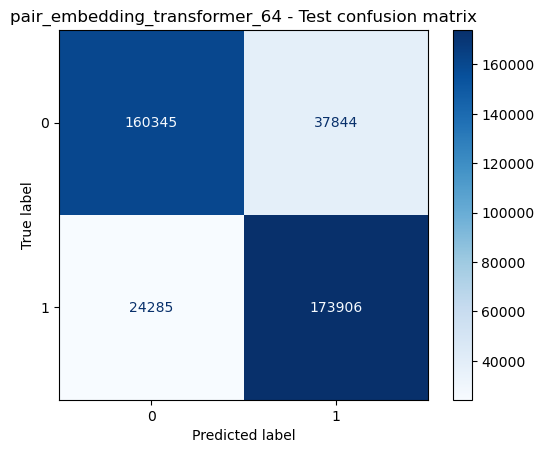

In [9]:
test_metrics = transformer_model.test_pipeline(
    df_test_model,
    batch_size=TRAINING_PARAMS["batch_size"],
)

The model performances over the unseen data (test set) reach 84.33% of accuracy, with similar number of true labels predictions. The models seems to have some difficult in identifying true negatives, correctly classifying 80% of the time.

## 4. Save the pretrained model
The PyTorch checkpoint is saved under `MODELZOO/textual_embeddings_64/`, together with the scaler, selected feature columns, threshold, training history, and metadata needed for inference.


In [10]:
summary = {
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
    "train_size": int(len(df_train_model)),
    "val_size": int(len(df_val_model)),
    "test_size": int(len(df_test_model)),
    "training_params": TRAINING_PARAMS,
    "history": transformer_model.history,
}

In [11]:
from utils.model_saver import save_model_artifact

save_model_artifact(transformer_model, df_name=text_emb_64.name, 
                    model_name="Best_Transformer_textual_64", 
                    relative_model_dir=MODEL_SAVE_PATH)

## 5. Load checkpoint for inference
This optional cell reloads a saved checkpoint so the model can be reused without retraining.


In [12]:
# Esempio di reload da checkpoint salvato:
# loaded_model = load_pair_embedding_transformer_model(
#     Path("Models/embeddings/pair_embedding_transformer_128/<checkpoint>.pt"),
#     device=DEVICE,
# )